# Método de Jacobi para sistemas de ecuaciones lineales

Implementación y aplicación del **método iterativo de Jacobi** para aproximar la solución de sistemas de ecuaciones lineales utilizando Python.

Este notebook reúne ejercicios desarrollados durante el estudio de **Análisis Numérico**, reorganizados y documentados para presentar de forma clara dos formas de implementar el método: mediante **sumatorias** y mediante **matrices**.

### Objetivos

- Comprender el esquema iterativo del método de Jacobi.
- Implementar el método mediante sumatorias.
- Implementar el método mediante matrices.
- Analizar la convergencia a partir del radio espectral.
- Comparar ambas implementaciones y verificar que producen aproximaciones equivalentes.

**Tecnologías:** Python · NumPy · Matplotlib

## 1. Fundamento del método

El **método de Jacobi** es un procedimiento iterativo utilizado para aproximar la solución de un sistema lineal:

$Ax=b$

Para cada componente del vector solución, el método puede expresarse mediante:

$$
x_i^{(k+1)}=
\frac{1}{a_{ii}}
\left(
b_i-
\sum_{\substack{j=1 \\ j\neq i}}^{n}
a_{ij}x_j^{(k)}
\right)
$$

donde $x^{(0)}$ es un vector inicial.

En cada iteración se calcula un nuevo vector utilizando únicamente los valores de la iteración anterior. Como criterio de parada se utiliza la diferencia entre dos aproximaciones consecutivas:

$$
\left\|x^{(k+1)}-x^{(k)}\right\|_{\infty}<\text{Tol}
$$

También es posible comprobar la aproximación mediante el residuo del sistema:

$$
\left\|Ax^{(k+1)}-b\right\|_{\infty}\approx 0
$$

### Sistema utilizado como ejemplo

$$
\begin{aligned}
3x_1-x_2 &= 2 \\
-x_1+4x_2-x_3 &= 3 \\
-x_2+5x_3 &= 5
\end{aligned}
$$

Se utiliza como valor inicial $x^{(0)}=(0,0,0)^T$.

## 2. Implementación mediante sumatorias

La primera implementación calcula cada componente del nuevo vector aplicando directamente la fórmula de Jacobi.

El siguiente código corresponde a la implementación original utilizada en los ejercicios.

In [1]:
import numpy as np

""" matrizCoeficientes : matriz A del sistema
    vectorIndependiente : vector b
    vectorInicial : valor inicial de las incógnitas
    tolerancia : criterio de paro
    maxIteraciones : límite de iteraciones
    """

def JacobiSumas(matrizCoeficientes, vectorIndependiente, vectorInicial, tolerancia, maxIteraciones=100):
    n = len(vectorIndependiente)
    vectorAnterior = vectorInicial.copy()
    
    for numeroIteracion in range(maxIteraciones):
        vectorNuevo = np.zeros_like(vectorAnterior, dtype=float)
        for i in range(n):
            suma = 0
            for j in range(n):
                if j != i:
                    suma += matrizCoeficientes[i][j] * vectorAnterior[j]
            vectorNuevo[i] = (vectorIndependiente[i] - suma) / matrizCoeficientes[i][i]
        error = np.linalg.norm(vectorNuevo - vectorAnterior, ord=np.inf)
        
        print(f"Iteración {numeroIteracion+1}: x = {vectorNuevo}, error = {error:.4f}")
        if error < tolerancia:
            return vectorNuevo, numeroIteracion+1
        vectorAnterior = vectorNuevo
    
    print("No convergió en el número máximo de iteraciones")
    return vectorAnterior, maxIteraciones

### Aplicación al sistema de ejemplo

Se utiliza una tolerancia de $10^{-6}$ y el vector inicial nulo. En cada iteración se muestra la aproximación obtenida y el error calculado con la norma infinito.

In [2]:
matrizCoeficientes = np.array([[3, -1, 0],[-1, 4, -1],[0, -1, 5]], float)
vectorIndependiente = np.array([2, 3, 5], float)
vectorInicial = np.zeros_like(vectorIndependiente)
tolerancia=1e-6
solucionAproximada, numeroIteraciones = JacobiSumas(matrizCoeficientes, vectorIndependiente, vectorInicial, tolerancia)
print("\nSolución aproximada:", solucionAproximada)
print("Iteraciones realizadas:", numeroIteraciones)

Iteración 1: x = [0.66666667 0.75       1.        ], error = 1.0000
Iteración 2: x = [0.91666667 1.16666667 1.15      ], error = 0.4167
Iteración 3: x = [1.05555556 1.26666667 1.23333333], error = 0.1389
Iteración 4: x = [1.08888889 1.32222222 1.25333333], error = 0.0556
Iteración 5: x = [1.10740741 1.33555556 1.26444444], error = 0.0185
Iteración 6: x = [1.11185185 1.34296296 1.26711111], error = 0.0074
Iteración 7: x = [1.11432099 1.34474074 1.26859259], error = 0.0025
Iteración 8: x = [1.11491358 1.3457284  1.26894815], error = 0.0010
Iteración 9: x = [1.1152428  1.34596543 1.26914568], error = 0.0003
Iteración 10: x = [1.11532181 1.34609712 1.26919309], error = 0.0001
Iteración 11: x = [1.11536571 1.34612872 1.26921942], error = 0.0000
Iteración 12: x = [1.11537624 1.34614628 1.26922574], error = 0.0000
Iteración 13: x = [1.11538209 1.3461505  1.26922926], error = 0.0000
Iteración 14: x = [1.1153835  1.34615284 1.2692301 ], error = 0.0000
Iteración 15: x = [1.11538428 1.3461534  1.

## 3. Implementación mediante matrices

El mismo método puede escribirse en forma matricial. Si la matriz de coeficientes se descompone utilizando su diagonal $D$ y las partes triangular inferior y superior, la iteración puede expresarse como:

$$
x^{(k+1)}=T_jx^{(k)}+C_j
$$

En la implementación utilizada:

$$
T_j=D^{-1}(L+U)
$$

y

$$
C_j=D^{-1}b
$$

Antes de comenzar las iteraciones se calculan los valores propios de $T_j$. El **radio espectral** está dado por:

$$
\rho(T_j)=\max_i |\lambda_i|
$$

La implementación considera que el proceso converge cuando:

$$
\rho(T_j)<1
$$

El siguiente código conserva la implementación original mediante matrices.

In [3]:
import time
import numpy as np

def JacobiMatrices(matrizCoeficientes, vectorIndependiente, x0, tolerancia):
    D=np.diag(np.diag(matrizCoeficientes))
    U=D-np.triu(matrizCoeficientes)
    L=D-np.tril(matrizCoeficientes)
    Tj=np.dot(np.linalg.inv(D), L+U)
    Cj=np.dot(np.linalg.inv(D), vectorIndependiente)
    eig, eiv=np.linalg.eig(Tj) # Esta rutina retorna 2 parametros: (Valores propios y vectores propios)
    radio=max(abs(eig))
    
    if (radio<1):
        print("Se logró")
        error=1
        iter = 0
        start = time.time()
        while (error>tolerancia):
            x_new=np.dot(Tj,x0)+Cj
            iter += 1
            print(x_new, "en la iteración:", iter)
            error=max(abs(x_new-x0))
            x0=x_new
        end = time.time()
        print("El tiempo de ejecución es:", end - start)
        return x_new
    else:
        print("El sistema no converge")
        return

### Aplicación al mismo sistema

Se resuelve nuevamente el sistema anterior, ahora utilizando la formulación matricial. Esto permite comparar el resultado con la implementación mediante sumatorias.

In [4]:
matrizCoeficientes = np.array([[3, -1, 0],[-1, 4, -1],[0, -1, 5]], float)
# Vector de soluciones
vectorIndependiente = np.array([2, 3, 5], float)
# Vector inicial, depende del problema (Puede ser cualquiera)
x0=np.zeros_like(vectorIndependiente) 

tolerancia = 1e-6
JacobiMatrices(matrizCoeficientes, vectorIndependiente, x0, tolerancia)

Se logró
[0.66666667 0.75       1.        ] en la iteración: 1
[0.91666667 1.16666667 1.15      ] en la iteración: 2
[1.05555556 1.26666667 1.23333333] en la iteración: 3
[1.08888889 1.32222222 1.25333333] en la iteración: 4
[1.10740741 1.33555556 1.26444444] en la iteración: 5
[1.11185185 1.34296296 1.26711111] en la iteración: 6
[1.11432099 1.34474074 1.26859259] en la iteración: 7
[1.11491358 1.3457284  1.26894815] en la iteración: 8
[1.1152428  1.34596543 1.26914568] en la iteración: 9
[1.11532181 1.34609712 1.26919309] en la iteración: 10
[1.11536571 1.34612872 1.26921942] en la iteración: 11
[1.11537624 1.34614628 1.26922574] en la iteración: 12
[1.11538209 1.3461505  1.26922926] en la iteración: 13
[1.1153835  1.34615284 1.2692301 ] en la iteración: 14
[1.11538428 1.3461534  1.26923057] en la iteración: 15
El tiempo de ejecución es: 0.0010814666748046875


array([1.11538428, 1.3461534 , 1.26923057])

## 4. Aplicación — Análisis de convergencia

Se considera el sistema:

$$
\begin{cases}
15x_1-3x_2-x_3=3800 \\
-3x_1+18x_2-6x_3=1200 \\
-4x_1-x_2+12x_3=2350
\end{cases}
$$

con el valor inicial:

$$
x^{(0)}=
\begin{pmatrix}
3\\
3\\
3
\end{pmatrix}
$$

En este ejercicio se calcula el radio espectral, se determina si el método converge, se muestran las tres primeras iteraciones y finalmente se obtiene una aproximación con tolerancia $10^{-6}$.

In [5]:
import numpy as np
import time

# Sistema dado
matrizCoeficientes = np.array([
    [15, -3, -1],
    [-3, 18, -6],
    [-4, -1, 12]
], float)

vectorIndependiente = np.array([3800, 1200, 2350], float)

# Solución inicial del enunciado
x0 = np.array([3, 3, 3], float)

def JacobiMatrices(matrizCoeficientes, vectorIndependiente, x0, tolerancia):
    D = np.diag(np.diag(matrizCoeficientes))
    U = D - np.triu(matrizCoeficientes)
    L = D - np.tril(matrizCoeficientes)

    # Matriz de iteración Jacobi
    Tj = np.dot(np.linalg.inv(D), (L + U))
    Cj = np.dot(np.linalg.inv(D), vectorIndependiente)

    # Calcular valores propios
    eig, eiv = np.linalg.eig(Tj)
    radio = max(abs(eig))
    print("Radio espectral ρ =", radio)

    if radio < 1:
        print("El método converge ")
        error = 1
        iter = 0

        start = time.time()
        while error > tolerancia:
            x_new = np.dot(Tj, x0) + Cj
            iter += 1
            if iter <= 3:  # Mostrar resultados hasta la 3ra iteración
                print(f"x^{iter} =", x_new)
            error = max(abs(x_new - x0))
            x0 = x_new
        end = time.time()

        print("\nSolución aproximada con tolerancia 1e-6:")
        print(x_new)
        print("Iteraciones totales:", iter)
        print("Tiempo de ejecución:", end - start, "segundos")
        return x_new
    else:
        print("El sistema no converge ")
        return

tolerancia = 1e-6
JacobiMatrices(matrizCoeficientes, vectorIndependiente, x0, tolerancia)


Radio espectral ρ = 0.3798364643610988
El método converge 
x^1 = [254.13333333  68.16666667 197.08333333]
x^2 = [280.10555556 174.71666667 286.225     ]
x^3 = [307.35833333 208.75925926 303.76157407]

Solución aproximada con tolerancia 1e-6:
[320.20725353 227.202072   321.50259024]
Iteraciones totales: 21
Tiempo de ejecución: 0.00039768218994140625 segundos


array([320.20725353, 227.202072  , 321.50259024])

## 5. Comparación entre Jacobi por sumatorias y por matrices

Las dos implementaciones representan el mismo método matemático. Para comprobarlo, se almacenan las aproximaciones generadas en cada iteración y se calcula la norma infinito de la diferencia entre ambos resultados:

$$
e_k=
\left\|
x_{\text{sumas}}^{(k)}
-
x_{\text{matrices}}^{(k)}
\right\|_{\infty}
$$

La gráfica permite observar si existe alguna diferencia numérica entre ambas implementaciones.

[Sumas] Iteración 1: x = [ 0.6         2.27272727 -1.1       ], error = 2.2727
[Sumas] Iteración 2: x = [ 1.04727273  2.22727273 -0.99272727], error = 0.4473
[Sumas] Iteración 3: x = [ 1.02127273  2.27768595 -1.08672727], error = 0.0940
[Sumas] Iteración 4: x = [ 1.04511405  2.26677686 -1.07648595], error = 0.0238
[Sumas] Iteración 5: x = [ 1.04197488  2.26987528 -1.08234512], error = 0.0059
[Sumas] Iteración 6: x = [ 1.04345655  2.26905725 -1.08140745], error = 0.0015
[Sumas] Iteración 7: x = [ 1.04318721  2.26927719 -1.08178559], error = 0.0004
[Sumas] Iteración 8: x = [ 1.04328484  2.26921833 -1.08170972], error = 0.0001
[Sumas] Iteración 9: x = [ 1.04326378  2.2692341  -1.08173513], error = 0.0000
[Sumas] Iteración 10: x = [ 1.04327044  2.26922988 -1.08172935], error = 0.0000
[Sumas] Iteración 11: x = [ 1.04326886  2.26923101 -1.0817311 ], error = 0.0000
[Sumas] Iteración 12: x = [ 1.04326932  2.26923071 -1.08173067], error = 0.0000
El método Jacobi (Matrices) converge
[Matrices]  

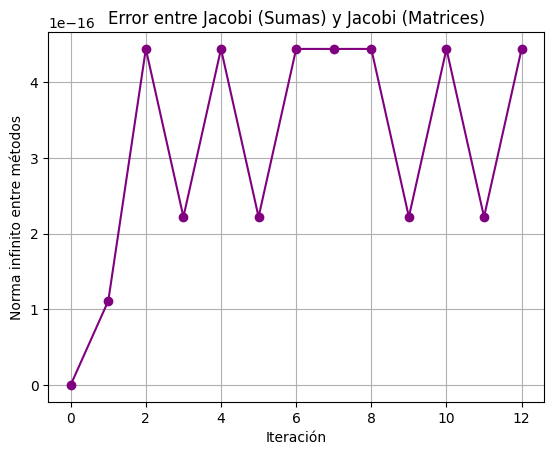

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt

def JacobiSumas(matrizCoeficientes, vectorIndependiente, vectorInicial, tolerancia, maxIteraciones=100):
    n = len(vectorIndependiente)
    vectorAnterior = vectorInicial.copy()
    historial = [vectorAnterior.copy()]  # Guardar x^(0)
    
    for numeroIteracion in range(maxIteraciones):
        vectorNuevo = np.zeros_like(vectorAnterior, dtype=float)
        
        # Calculamos cada componente de x^{(k+1)}
        for i in range(n):
            suma = 0
            for j in range(n):
                if j != i:
                    suma += matrizCoeficientes[i][j] * vectorAnterior[j]
            vectorNuevo[i] = (vectorIndependiente[i] - suma) / matrizCoeficientes[i][i]
        
        # Guardamos el nuevo vector
        historial.append(vectorNuevo.copy())
        
        # Calculamos el error con norma infinito
        error = np.linalg.norm(vectorNuevo - vectorAnterior, ord=np.inf)
        print(f"[Sumas] Iteración {numeroIteracion+1}: x = {vectorNuevo}, error = {error:.4f}")
        
        # Condición de parada
        if error < tolerancia:
            return vectorNuevo, numeroIteracion+1, historial
        vectorAnterior = vectorNuevo
    
    print("No convergió en el número máximo de iteraciones (Sumas)")
    return vectorAnterior, maxIteraciones, historial

def JacobiMatrices(matrizCoeficientes, vectorIndependiente, x0, tolerancia, maxIteraciones=100):
    D = np.diag(np.diag(matrizCoeficientes))
    U = D - np.triu(matrizCoeficientes)
    L = D - np.tril(matrizCoeficientes)
    Tj = np.dot(np.linalg.inv(D), L+U)
    Cj = np.dot(np.linalg.inv(D), vectorIndependiente)
    eig, eiv = np.linalg.eig(Tj)  
    radio = max(abs(eig))
    
    historial = [x0.copy()]  # Guardar x^(0)
    
    if (radio < 1):
        print("El método Jacobi (Matrices) converge")
        error = 1
        iter = 0
        start = time.time()
        while error > tolerancia and iter < maxIteraciones:
            x_new = np.dot(Tj, x0) + Cj
            iter += 1
            historial.append(x_new.copy())
            print("[Matrices] ", x_new, "en la iteración:", iter)
            error = max(abs(x_new - x0))
            x0 = x_new
        end = time.time()
        print("El tiempo de ejecución es:", end - start)
        return x_new, iter, historial
    else:
        print("El sistema no converge (Matrices)")
        return x0, 0, historial

# Sistema de ejemplo
A = np.array([[10, -1, 2], [-1, 11, -1], [2, -1, 10]], dtype=float)
b = np.array([6, 25, -11], dtype=float)
x0 = np.zeros(len(b))

# Ejecutamos Jacobi
sol_sumas, it_sumas, hist_sumas = JacobiSumas(A, b, x0, 1e-6, 25)
sol_mat, it_mat, hist_mat = JacobiMatrices(A, b, x0, 1e-6, 25)

# Calculamos las normas entre iteraciones
n_iter = min(len(hist_sumas), len(hist_mat))
errores = []

for k in range(n_iter):
    diff = np.linalg.norm(hist_sumas[k] - hist_mat[k], ord=np.inf)
    errores.append(diff)

# Graficamos errores
plt.plot(range(n_iter), errores, marker='o', color='purple')
plt.xlabel("Iteración")
plt.ylabel("Norma infinito entre métodos")
plt.title("Error entre Jacobi (Sumas) y Jacobi (Matrices)")
plt.grid(True)
plt.show()

### Análisis de la gráfica

Ambas implementaciones producen la misma sucesión de aproximaciones, con diferencias únicamente asociadas a la precisión numérica de las operaciones realizadas por el computador.

Por esta razón, la norma de la diferencia entre los vectores de cada iteración permanece prácticamente en cero. Las pequeñas variaciones observadas corresponden al orden de magnitud del error de redondeo de punto flotante.

La comparación confirma que las implementaciones mediante **sumatorias** y mediante **matrices** representan el mismo esquema iterativo de Jacobi.

## 6. Conclusiones

A partir de las implementaciones y ejercicios desarrollados se puede concluir que:

- El método de Jacobi permite aproximar la solución de sistemas de ecuaciones lineales mediante un proceso iterativo.
- La implementación puede realizarse directamente mediante sumatorias o utilizando una formulación matricial.
- El criterio de parada puede establecerse mediante la norma de la diferencia entre aproximaciones consecutivas.
- En la formulación matricial, el radio espectral de la matriz de iteración permite analizar la convergencia del método.
- Las implementaciones mediante sumatorias y matrices producen resultados equivalentes, salvo pequeñas diferencias asociadas al redondeo numérico.
- La elección del sistema y sus propiedades influye directamente en la convergencia del método.